Data Preparation Summary

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('Data/E Commerce Customer Insights and Churn Dataset.csv')
df.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39,PROD200,Canada,1/7/2021,2/21/2023,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61,PROD201,USA,10/19/2020,12/8/2021,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26,PROD202,Pakistan,6/10/2023,9/4/2023,3,cancelled,3/12/2025,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54,PROD203,India,7/30/2023,2/20/2024,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50,PROD204,India,12/9/2020,9/14/2024,0,active,8/8/2024,62.66,7,35,Sports,Smartwatch,Electronics,Male


In [6]:
df.shape

(2000, 17)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             2000 non-null   str    
 1   customer_id          2000 non-null   str    
 2   age                  2000 non-null   int64  
 3   product_id           2000 non-null   str    
 4   country              2000 non-null   str    
 5   signup_date          2000 non-null   str    
 6   last_purchase_date   2000 non-null   str    
 7   cancellations_count  2000 non-null   int64  
 8   subscription_status  2000 non-null   str    
 9   order_date           2000 non-null   str    
 10  unit_price           2000 non-null   float64
 11  quantity             2000 non-null   int64  
 12  purchase_frequency   2000 non-null   int64  
 13  preferred_category   2000 non-null   str    
 14  product_name         2000 non-null   str    
 15  category             2000 non-null   str    
 16 

In [8]:
df.isnull().sum()

order_id               0
customer_id            0
age                    0
product_id             0
country                0
signup_date            0
last_purchase_date     0
cancellations_count    0
subscription_status    0
order_date             0
unit_price             0
quantity               0
purchase_frequency     0
preferred_category     0
product_name           0
category               0
gender                 0
dtype: int64

In [9]:
df.describe()

,age,cancellations_count,unit_price,quantity,purchase_frequency
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,44.080500,2.441500,324.719460,4.948500,25.158000
std,14.798091,1.702359,361.548405,2.557757,14.158752
min,18.000000,0.000000,2.850000,1.000000,1.000000
25%,31.000000,1.000000,111.127500,3.000000,13.000000
50%,45.000000,2.000000,206.515000,5.000000,25.000000
75%,57.000000,4.000000,384.507500,7.000000,37.000000
max,69.000000,5.000000,1991.630000,9.000000,49.000000


In [10]:
date_cols = ['signup_date','order_date', 'last_purchase_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df[date_cols].dtypes
    

signup_date           datetime64[us]
order_date            datetime64[us]
last_purchase_date    datetime64[us]
dtype: object

In [11]:
df['order_amount'] = df['quantity'] * df['unit_price'] # total_spendings

In [12]:
reference_date = df['last_purchase_date'].max() + pd.Timedelta(days=1)  # Reference date
reference_date

Timestamp('2025-08-21 00:00:00')

In [13]:
# RFM features
df['recency_days'] = (reference_date - df['last_purchase_date']).dt.days
df['frequency'] = df['purchase_frequency']
df['monetary'] = df['order_amount']

In [14]:
#drop 'purchase_frequency' column
df.drop(columns=['purchase_frequency'], inplace = True) 

In [15]:
# 2.2.1 Disclose customer lifecycle
df['tenure_days'] = (reference_date - df['signup_date']).dt.days
df['avg_order_value'] = np.where(df['frequency']>0,df['monetary']/df['frequency'],0)
# 2.2.2 Engagement
df['purchase_intensity'] = np.where(df['tenure_days'] > 0,df['frequency'] / df['tenure_days'],0)
df['inactive_ratio'] = np.where(df['tenure_days']>0,df['recency_days']/df['tenure_days'],0)

3. Check Outlier

In [16]:
# Non numerical columns
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['order_id', 'customer_id', 'product_id', 'country',
       'subscription_status', 'preferred_category', 'product_name', 'category',
       'gender'],
      dtype='str')

In [17]:
for col in cat_cols:
    print(f"{col}:{df[col].nunique()} unique value")  # Number of unique values

order_id:2000 unique value
customer_id:2000 unique value
product_id:2000 unique value
country:6 unique value
subscription_status:3 unique value
preferred_category:5 unique value
product_name:40 unique value
category:5 unique value
gender:3 unique value


In [18]:
# Check unique values
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())


order_id:
<StringArray>
['ORD5000', 'ORD5001', 'ORD5002', 'ORD5003', 'ORD5004', 'ORD5005', 'ORD5006',
 'ORD5007', 'ORD5008', 'ORD5009',
 ...
 'ORD6990', 'ORD6991', 'ORD6992', 'ORD6993', 'ORD6994', 'ORD6995', 'ORD6996',
 'ORD6997', 'ORD6998', 'ORD6999']
Length: 2000, dtype: str

customer_id:
<StringArray>
['CUST1000', 'CUST1001', 'CUST1002', 'CUST1003', 'CUST1004', 'CUST1005',
 'CUST1006', 'CUST1007', 'CUST1008', 'CUST1009',
 ...
 'CUST2990', 'CUST2991', 'CUST2992', 'CUST2993', 'CUST2994', 'CUST2995',
 'CUST2996', 'CUST2997', 'CUST2998', 'CUST2999']
Length: 2000, dtype: str

product_id:
<StringArray>
[ 'PROD200',  'PROD201',  'PROD202',  'PROD203',  'PROD204',  'PROD205',
  'PROD206',  'PROD207',  'PROD208',  'PROD209',
 ...
 'PROD2190', 'PROD2191', 'PROD2192', 'PROD2193', 'PROD2194', 'PROD2195',
 'PROD2196', 'PROD2197', 'PROD2198', 'PROD2199']
Length: 2000, dtype: str

country:
<StringArray>
['Canada', 'USA', 'Pakistan', 'India', 'Germany', 'UK']
Length: 6, dtype: str

subscription_st

In [19]:
# Value counts
for col in cat_cols:
    print(f"\n{col} distribution:")
    print(df[col].value_counts())


order_id distribution:
order_id
ORD5000    1
ORD5001    1
ORD5002    1
ORD5003    1
ORD5004    1
          ..
ORD6995    1
ORD6996    1
ORD6997    1
ORD6998    1
ORD6999    1
Name: count, Length: 2000, dtype: int64

customer_id distribution:
customer_id
CUST1000    1
CUST1001    1
CUST1002    1
CUST1003    1
CUST1004    1
           ..
CUST2995    1
CUST2996    1
CUST2997    1
CUST2998    1
CUST2999    1
Name: count, Length: 2000, dtype: int64

product_id distribution:
product_id
PROD200     1
PROD201     1
PROD202     1
PROD203     1
PROD204     1
           ..
PROD2195    1
PROD2196    1
PROD2197    1
PROD2198    1
PROD2199    1
Name: count, Length: 2000, dtype: int64

country distribution:
country
Germany     360
UK          350
Pakistan    332
India       324
USA         319
Canada      315
Name: count, dtype: int64

subscription_status distribution:
subscription_status
active       1204
cancelled     493
paused        303
Name: count, dtype: int64

preferred_category distribution

In [20]:
# Select numerical columns for outlier detection
num_cols = [
    'age', 'quantity', 'unit_price',
    'frequency', 'monetary',
    'recency_days', 'tenure_days',
    'avg_order_value', 'purchase_intensity'
]

df[num_cols].head()

,age,quantity,unit_price,frequency,monetary,recency_days,tenure_days,avg_order_value,purchase_intensity
0,39,5,78.21,37,391.05,912,1687,10.568919,0.021932
1,61,8,64.02,35,512.16,1352,1767,14.633143,0.019808
2,26,2,604.14,44,1208.28,717,803,27.460909,0.054795
3,54,4,84.66,1,338.64,548,753,338.640000,0.001328
4,50,7,62.66,35,438.62,341,1716,12.532000,0.020396


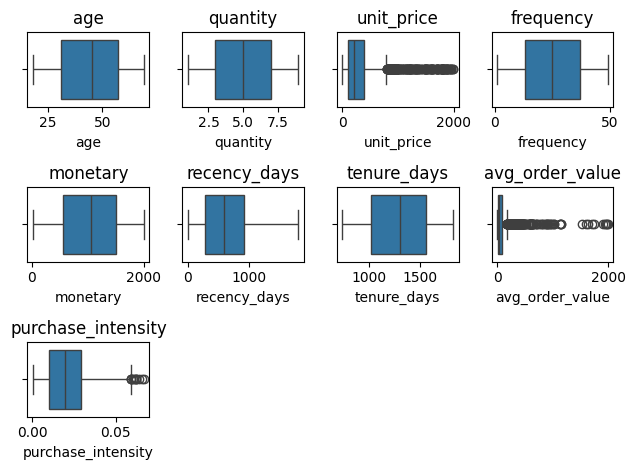

In [21]:
# Boxplots for outlier detection

plt.Figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [22]:
def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = len(outliers)

    return outlier_summary

# Run detection
outliers = detect_outliers_iqr(df, num_cols)

print("Outlier count per column:")
print(outliers)
     

Outlier count per column:
{'age': 0, 'quantity': 0, 'unit_price': 186, 'frequency': 0, 'monetary': 0, 'recency_days': 0, 'tenure_days': 0, 'avg_order_value': 215, 'purchase_intensity': 11}


In [24]:
print('='*60)
print('final data cleaning report')
print('='*60)

final data cleaning report


In [26]:
# 1. Missing values
missing = df.isnull().sum()
missing_pct = (missing/ len(df))*100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct%': missing_pct.round(2)
})

missing_df = missing_df[missing_df['missing_count']>0]

print("\nmissing values per varisble :")
print(missing_df if not missing_df.empty else "No missing values")


# 2. Duplicate check
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")

# 3. Unique counts (key categorical variables)
cat_cols = df.select_dtypes(include='object').columns

print("\ncategarical columns summery:")
for col in cat_cols:
    print(f"{col}:{df[col].nunique()} unique values")

# 4. Dataset structure
print(f"no of rows:{df.shape[0]}")
print(f'no of rows:{df.shape[0]}')

# 5. Customer uniqueness (VERY IMPORTANT ⭐)
unique_customer = df['customer_id'].nunique()
print(f"\nunique customer count:{unique_customer}/{len(df)}")

if unique_customer == len(df):
    print("✓ Dataset is at customer-level (no duplicates per customer)")
else:
    print('⚠ Multiple rows per customer detected')

# 6. Final check summary
print("\nOverall Data Quality Status:")
if missing_df.empty and dup_count == 0:
    print("✓ Clean dataset — no missing values and no duplicates")
else:
    print("⚠ Data requires further cleaning")

print("="*60)


missing values per varisble :
No missing values

Duplicate rows: 0

categarical columns summery:
order_id:2000 unique values
customer_id:2000 unique values
product_id:2000 unique values
country:6 unique values
subscription_status:3 unique values
preferred_category:5 unique values
product_name:40 unique values
category:5 unique values
gender:3 unique values
no of rows:2000
no of rows:2000

unique customer count:2000/2000
✓ Dataset is at customer-level (no duplicates per customer)

Overall Data Quality Status:
✓ Clean dataset — no missing values and no duplicates


In [27]:
# Export cleaned dataset
df.to_csv("cleaned_ecommerce_churn_dataset.csv", index=False)